In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("mushrooms.csv")

print("Shape:", df.shape)
df.head()

Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [ ]:
#lets explore teh dasta abit more now 

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [6]:
df['class'].value_counts()


class
e    4208
p    3916
Name: count, dtype: int64

In [8]:
print("NaN counts:\n", df.isna().sum().sum())
for col in df.columns:
    if (df[col] == '?').any():
        print(f"Column '{col}' has {(df[col]=='?').sum()} '?' entries")


NaN counts:
 0
Column 'stalk-root' has 2480 '?' entries


the entire dataset has no nans but alot of ? entries
we will keep them as they are as dropping them would lose us alot of 

now we go into  encoding

In [9]:
encoders = {}
df_encoded = df.copy()

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

df_encoded.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,0,3,2,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,0,2,2,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,0,2,2,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,0,3,2,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,1,3,2,2,7,7,0,2,1,0,3,0,1


In [10]:
#split featuresss
X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target classes:", dict(zip(encoders['class'].classes_, encoders['class'].transform(encoders['class'].classes_))))

X shape: (8124, 22)
y shape: (8124,)
Target classes: {'e': np.int64(0), 'p': np.int64(1)}


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (6499, 22)
Test shape: (1625, 22)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data mean (~0):", X_train_scaled.mean().round(3))
print("Scaled training data std (~1):", X_train_scaled.std().round(3))

Scaled training data mean (~0): 0.0
Scaled training data std (~1): 0.977


we are done with data cleaning and splitting lets get into implemetning

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score


k_values = range(2, 151)

train_f1_scores = []
test_f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)

    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)

print("Done training for K = 2 to 150")

Done training for K = 2 to 150


In [15]:
results_df = pd.DataFrame({
    'K': list(k_values),
    'Train_F1': train_f1_scores,
    'Test_F1': test_f1_scores
})

results_df.head(10)

best_row = results_df.loc[results_df['Test_F1'].idxmax()]
print("Best K by test F1-score:", int(best_row['K']))
print("Test F1 at that K:", round(best_row['Test_F1'], 4))

Best K by test F1-score: 2
Test F1 at that K: 1.0


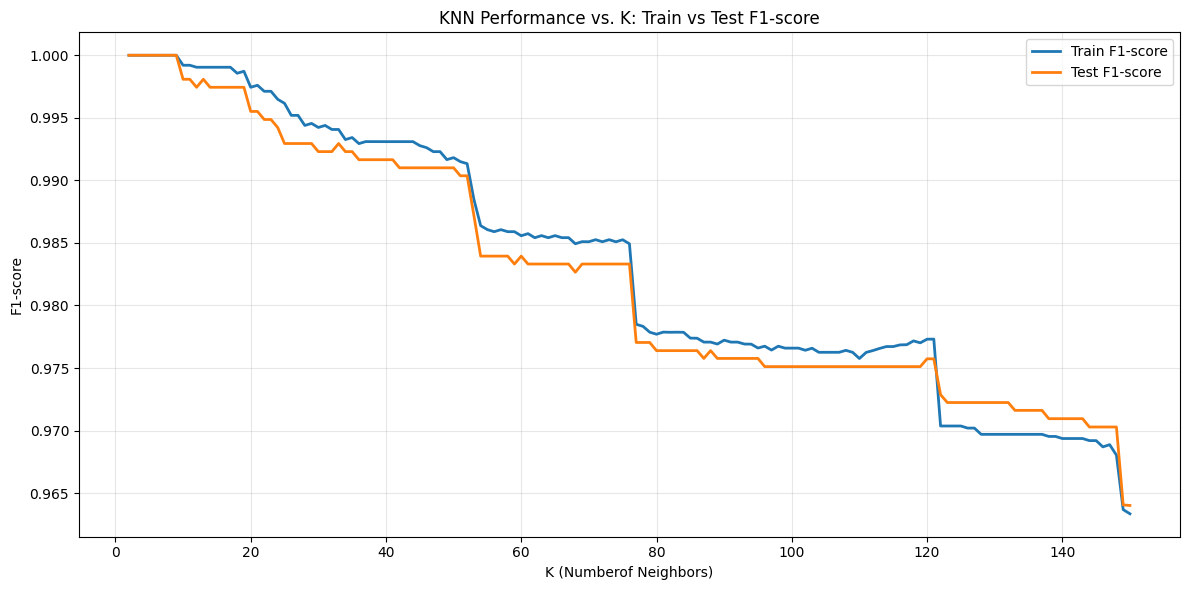

In [19]:

plt.figure(figsize=(12, 6))
plt.plot(results_df['K'], results_df['Train_F1'], label='Train F1-score', linewidth=2)
plt.plot(results_df['K'], results_df['Test_F1'], label='Test F1-score', linewidth=2)

plt.xlabel('K (Numberof Neighbors)')
plt.ylabel('F1-score')
plt.title('KNN Performance vs. K: Train vs Test F1-score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
best_k = int(best_row['K'])
best_test_f1 = best_row['Test_F1']
best_train_f1 = best_row['Train_F1']

print(f"Best K (by test F1-score): {best_k}")
print(f"Train F1 at K={best_k}: {best_train_f1:.4f}")
print(f"Test F1 at K={best_k}: {best_test_f1:.4f}")

Best K (by test F1-score): 2
Train F1 at K=2: 1.0000
Test F1 at K=2: 1.0000


In [18]:
results_df['Gap'] = results_df['Train_F1'] - results_df['Test_F1']

print("llargest train-test gaps (potential overfitting zone):")
print(results_df.sort_values('Gap', ascending=False).head(5))

print("\nSmallest F1 scores overall (potential underfitting zone):")
print(results_df.sort_values('Test_F1').head(5))

llargest train-test gaps (potential overfitting zone):
     K  Train_F1   Test_F1       Gap
23  25  0.996160  0.992944  0.003216
57  59  0.985897  0.983312  0.002585
52  54  0.986376  0.983943  0.002433
59  61  0.985739  0.983312  0.002428
66  68  0.984931  0.982659  0.002272

Smallest F1 scores overall (potential underfitting zone):
       K  Train_F1   Test_F1       Gap
148  150  0.963346  0.964010 -0.000665
147  149  0.963680  0.964056 -0.000376
142  144  0.969196  0.970284 -0.001088
146  148  0.968035  0.970284 -0.002249
145  147  0.968872  0.970284 -0.001413


analysis :
Overfitting: As K increases, the model relies on more neighbors, which typically 
  reduces variance but can increase bias. Look for where Train F1 stays high while 
  Test F1 drops — that's the overfitting-to-underfitting transition


Underfitting:At very large K (approaching 150), the model averages over too many 
  neighbors and starts losing the ability to separate classes — watch both curves decline.
Best K:State the K value with highest test F1, and note if multiple K values tie 
  near the top (common with a highly separable dataset like this one)

